# LLM Evaluation Harness
### Advait Kulkarni | Imperial College London MSc AML

**A systematic benchmarking framework for open-source LLMs across reasoning, instruction-following and domain knowledge tasks.**

Models evaluated: `Qwen/Qwen2.5-0.5B-Instruct` · `microsoft/Phi-3-mini-4k-instruct` · `meta-llama/Llama-3.2-1B-Instruct`

---
### Notebook Structure
1. Setup & Installs
2. Model Loading (CPU-friendly, 4-bit quantised)
3. Evaluation Framework
4. Task 1 — Mathematical Reasoning (GSM8K-style)
5. Task 2 — Instruction Following (IFEval-style)
6. Task 3 — Domain Knowledge (STEM Q&A)
7. Failure Mode Analysis
8. Efficiency vs. Accuracy Trade-off
9. Results Summary & Visualisations
10. Key Findings

## Cell 1 — Install Dependencies

In [1]:
# Install required packages
# NOTE: If running on Colab, Runtime > Change runtime type > T4 GPU (optional but faster)
# All models run fine on CPU for evaluation — just slower (~2-5 min per task set)

import subprocess, sys

pkgs = [
    'transformers>=4.40.0',
    'torch',
    'accelerate',
    'bitsandbytes',   # for 4-bit quantisation (GPU only — skip on CPU)
    'sentencepiece',
    'protobuf',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scipy',
    'datasets',       # HuggingFace datasets for GSM8K
    'evaluate',       # HuggingFace metrics
    'rouge_score',
    'tqdm',
]
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p])

print('All packages installed.')

All packages installed.


## Cell 2 — Imports & Config

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, re, json, time, random
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional
from tqdm.auto import tqdm
from IPython.display import display, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline,
    set_seed,
)

# ── Reproducibility ───────────────────────────────────────────
set_seed(42)
random.seed(42)
np.random.seed(42)

# ── Output folder ─────────────────────────────────────────────
Path('results').mkdir(exist_ok=True)

# ── Device ────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})

PALETTE = {
    'Qwen2.5-0.5B':  '#00e5a0',
    'Phi-3-mini':    '#4d9aff',
    'Llama-3.2-1B':  '#ff6b6b',
}
MODEL_COLORS = list(PALETTE.values())

print('Setup complete.')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Setup complete.


In [13]:
# ── CELL: Permanent fix — run this, then re-run Cell 3 and Cell 6 ──

# Option 1 (fastest): delete the broken cached file so transformers
# uses its own built-in Phi-3 class instead of the remote code
import shutil, os
from pathlib import Path

cache_root = Path.home() / '.cache' / 'huggingface' / 'hub'
phi_dirs = list(cache_root.glob('models--microsoft--Phi*'))

for d in phi_dirs:
    print(f'Removing cached Phi model: {d}')
    shutil.rmtree(d, ignore_errors=True)

print('Cache cleared. Now re-run Cell 3 and Cell 6.')
print('The model will re-download (~7.5 GB) but load correctly this time.')

Removing cached Phi model: /root/.cache/huggingface/hub/models--microsoft--Phi-3-mini-4k-instruct
Cache cleared. Now re-run Cell 3 and Cell 6.
The model will re-download (~7.5 GB) but load correctly this time.


## Cell 3 — Model Registry & Loader

In [14]:
## Cell 3 — FIXED Model Registry & Loader
#
# Replace your entire Cell 3 with this code.
# Fixes:
#   1. Phi-3-mini rope_scaling KeyError (transformers version mismatch)
#   2. More robust pipeline creation per model family
#   3. Graceful fallback for trust_remote_code issues

import warnings
warnings.filterwarnings('ignore')

# ── Fix Phi-3 rope_scaling bug BEFORE loading ─────────────────
# Phi-3-mini has a rope_scaling config that uses "rope_type" in newer
# transformers versions but "type" in older ones. We patch it at load time.

from transformers import AutoConfig

def patch_phi3_config(hf_id: str) -> None:
    """
    Pre-patch Phi-3 config to fix rope_scaling KeyError.
    Must be called before AutoModelForCausalLM.from_pretrained().
    """
    if 'phi' not in hf_id.lower() and 'Phi' not in hf_id:
        return
    try:
        cfg = AutoConfig.from_pretrained(hf_id, trust_remote_code=True)
        if hasattr(cfg, 'rope_scaling') and cfg.rope_scaling is not None:
            rs = cfg.rope_scaling
            # Add 'type' key if missing (older transformers expects it)
            if 'type' not in rs and 'rope_type' in rs:
                rs['type'] = rs['rope_type']
                cfg.rope_scaling = rs
                print(f'  Patched rope_scaling: added type={rs["type"]}')
            # Add 'rope_type' if missing (newer transformers expects it)
            elif 'rope_type' not in rs and 'type' in rs:
                rs['rope_type'] = rs['type']
                cfg.rope_scaling = rs
                print(f'  Patched rope_scaling: added rope_type={rs["rope_type"]}')
    except Exception as e:
        print(f'  Config patch skipped: {e}')


# ── Model registry ────────────────────────────────────────────
MODEL_CONFIGS = [
    {
        'name':   'Qwen2.5-0.5B',
        'hf_id':  'Qwen/Qwen2.5-0.5B-Instruct',
        'params': '0.5B',
        'family': 'Qwen',
        'color':  PALETTE['Qwen2.5-0.5B'],
    },

    {
        'name':   'Phi-3.5-mini',
        'hf_id':  'microsoft/Phi-3.5-mini-instruct',
        'params': '3.8B',
        'family': 'Phi',
        'color':  PALETTE['Phi-3-mini'],
    },

    {
        'name':   'Llama-3.2-1B',
        'hf_id':  'meta-llama/Llama-3.2-1B-Instruct',
        'params': '1B',
        'family': 'Llama',
        'color':  PALETTE['Llama-3.2-1B'],
    },
]


def load_model(config: dict, quantise: bool = False):
    """
    Load a model and tokenizer. Handles model-specific quirks.
    Returns (tokenizer, model, pipeline).
    """
    hf_id  = config['hf_id']
    name   = config['name']
    family = config['family']
    print(f'\nLoading {name} ({hf_id}) ...')

    # ── Step 1: patch config for Phi-3 before loading ─────────
    patch_phi3_config(hf_id)

    # ── Step 2: tokenizer ─────────────────────────────────────
    tok_kwargs = dict(trust_remote_code=True)
    if family == 'Llama':
        tok_kwargs['use_fast'] = True

    tokenizer = AutoTokenizer.from_pretrained(hf_id, **tok_kwargs)

    # Ensure pad token exists
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    # ── Step 3: model load kwargs ─────────────────────────────
    dtype = torch.float16 if DEVICE == 'cuda' else torch.float32

    load_kwargs = dict(
        trust_remote_code=False,
        torch_dtype=dtype,
        low_cpu_mem_usage=True,
    )

    # device_map only on GPU — causes issues on CPU for some models
    if DEVICE == 'cuda':
        load_kwargs['device_map'] = 'auto'

    # 4-bit quantisation (GPU only)
    if quantise and DEVICE == 'cuda':
        from transformers import BitsAndBytesConfig
        bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        load_kwargs['quantization_config'] = bnb_cfg
        print('  4-bit NF4 quantisation enabled')

    # Phi-3 specific: attn_implementation may need to be eager on CPU
    if family == 'Phi' and DEVICE == 'cpu':
        load_kwargs['attn_implementation'] = 'eager'
        print('  Using eager attention (CPU mode for Phi-3)')

    # ── Step 4: load model ────────────────────────────────────
    model = AutoModelForCausalLM.from_pretrained(hf_id, **load_kwargs)

    if DEVICE == 'cpu':
        model = model.to('cpu')
    model.eval()

    # ── Step 5: pipeline ──────────────────────────────────────
    pipe_kwargs = dict(
        model=model,
        tokenizer=tokenizer,
        torch_dtype=dtype,
        trust_remote_code=True,
    )
    if DEVICE == 'cuda':
        pipe_kwargs['device_map'] = 'auto'
    else:
        pipe_kwargs['device'] = -1   # CPU

    pipe = pipeline('text-generation', **pipe_kwargs)

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  ✓ Loaded {name}: {n_params:.0f}M parameters on {DEVICE}')
    return tokenizer, model, pipe


def generate(
    pipe,
    prompt: str,
    max_new_tokens: int = 256,
    temperature: float = 0.0,
    system_prompt: str = 'You are a helpful, precise assistant.',
) -> tuple:
    """
    Generate a response. Returns (response_text, latency_seconds).
    temperature=0.0 → greedy decoding (deterministic, best for evals).
    """
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': prompt},
    ]

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=False,          # greedy — deterministic
        temperature=None,         # must be None when do_sample=False
        top_p=None,               # must be None when do_sample=False
        pad_token_id=pipe.tokenizer.eos_token_id,
        return_full_text=False,
    )

    t0 = time.time()
    try:
        # Some models don't support the messages format directly —
        # fall back to applying the chat template manually if needed
        try:
            out = pipe(messages, **gen_kwargs)
            response = out[0]['generated_text']
            if isinstance(response, list):
                # Some pipelines return list of dicts
                response = response[-1].get('content', str(response))
        except Exception:
            # Fallback: apply chat template manually
            text = pipe.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
            out = pipe(text, **gen_kwargs)
            response = out[0]['generated_text']

        response = str(response).strip()

    except Exception as e:
        response = f'[ERROR: {e}]'

    latency = time.time() - t0
    return response, latency


# ── Quick smoke test ──────────────────────────────────────────
print('Model loader ready.')
print(f'Will evaluate: {[m["name"] for m in MODEL_CONFIGS]}')
print(f'Device: {DEVICE}')
print('\nTip: Set MAX_PER_TASK = 3 in Cell 6 for a quick sanity check first.')

Model loader ready.
Will evaluate: ['Qwen2.5-0.5B', 'Phi-3.5-mini', 'Llama-3.2-1B']
Device: cuda

Tip: Set MAX_PER_TASK = 3 in Cell 6 for a quick sanity check first.


## Cell 4 — Task Definitions & Datasets

In [15]:
# ═══════════════════════════════════════════════════════════════
#  TASK 1 — MATHEMATICAL REASONING (GSM8K-style)
#
#  Tests multi-step arithmetic reasoning.
#  Grading: exact final answer match (extract last number from response).
#  We use 30 hand-curated problems at three difficulty levels.
# ═══════════════════════════════════════════════════════════════

MATH_PROBLEMS = [
    # ── Easy (single-step or simple two-step) ─────────────────
    {'q': 'A bakery makes 240 cookies per day. If they sell 75% of them, how many cookies are left unsold?',
     'a': '60', 'difficulty': 'easy'},
    {'q': 'A train travels at 80 km/h. How far does it travel in 3.5 hours?',
     'a': '280', 'difficulty': 'easy'},
    {'q': 'A rectangle has length 15 cm and width 8 cm. What is its area in square cm?',
     'a': '120', 'difficulty': 'easy'},
    {'q': 'If a shirt costs £45 and is discounted by 20%, what is the sale price in pounds?',
     'a': '36', 'difficulty': 'easy'},
    {'q': 'A factory produces 1200 units per hour. How many units does it produce in an 8-hour shift?',
     'a': '9600', 'difficulty': 'easy'},
    {'q': 'A store buys apples at £0.30 each and sells them at £0.50 each. If they sell 200 apples, what is the profit in pounds?',
     'a': '40', 'difficulty': 'easy'},
    {'q': 'A car uses 6 litres of fuel per 100 km. How many litres does it need for a 450 km journey?',
     'a': '27', 'difficulty': 'easy'},
    {'q': 'A worker earns £15 per hour and works 38 hours per week. What is their weekly wage?',
     'a': '570', 'difficulty': 'easy'},
    {'q': 'There are 52 cards in a deck. If 13 are hearts, what percentage are hearts?',
     'a': '25', 'difficulty': 'easy'},
    {'q': 'A container holds 5 litres. How many 250 ml glasses can be filled from it?',
     'a': '20', 'difficulty': 'easy'},

    # ── Medium (multi-step, requires intermediate reasoning) ───
    {'q': 'Alice has 3 times as many marbles as Bob. Bob has 12 more than Carol. Carol has 8 marbles. How many does Alice have?',
     'a': '60', 'difficulty': 'medium'},
    {'q': 'A bank account earns 5% simple interest per year. If £2000 is deposited, how much interest is earned over 3 years?',
     'a': '300', 'difficulty': 'medium'},
    {'q': 'A pump fills a tank at 40 litres per minute. The tank holds 2400 litres. If the tank is already 25% full, how many minutes to fill it completely?',
     'a': '45', 'difficulty': 'medium'},
    {'q': 'A recipe needs 2.5 cups of flour for 12 muffins. How many cups of flour are needed for 30 muffins?',
     'a': '6.25', 'difficulty': 'medium'},
    {'q': 'A team completes a project in 12 days with 5 workers. If 3 more workers join from day 4, how many total days does the project take? Assume constant daily progress per worker.',
     'a': '7.5', 'difficulty': 'medium'},
    {'q': 'A shopkeeper bought 50 kg of rice at £1.20 per kg and 30 kg at £1.50 per kg. He mixes them and sells at £1.45 per kg. What is his total profit in pounds?',
     'a': '7.5', 'difficulty': 'medium'},
    {'q': 'A car travels the first half of a journey at 60 km/h and the second half at 40 km/h. What is the average speed for the whole journey?',
     'a': '48', 'difficulty': 'medium'},
    {'q': 'If 8 machines produce 360 units in 3 hours, how many units will 5 machines produce in 6 hours?',
     'a': '450', 'difficulty': 'medium'},
    {'q': 'A store has a buy-2-get-1-free offer on £12 items. How much do you pay for 9 items?',
     'a': '72', 'difficulty': 'medium'},
    {'q': 'The sum of three consecutive even numbers is 78. What is the largest of the three?',
     'a': '28', 'difficulty': 'medium'},

    # ── Hard (multi-step, requires careful setup) ──────────────
    {'q': 'A 40-litre mixture of milk and water is in the ratio 3:1. How many litres of water must be added to make the ratio 3:2?',
     'a': '10', 'difficulty': 'hard'},
    {'q': 'Two pipes A and B can fill a tank in 12 and 18 hours respectively. Pipe C can drain it in 9 hours. If all three are open, how many hours to fill the tank?',
     'a': '36', 'difficulty': 'hard'},
    {'q': 'A sum of money doubles itself in 8 years at compound interest. In how many years will it become 4 times the original amount?',
     'a': '16', 'difficulty': 'hard'},
    {'q': 'A boat travels 30 km upstream and 30 km downstream. Its speed in still water is 10 km/h and the stream speed is 2 km/h. What is the total journey time in hours?',
     'a': '6.25', 'difficulty': 'hard'},
    {'q': 'In a class of 50 students, 60% passed Maths and 70% passed English. At least how many students passed both?',
     'a': '15', 'difficulty': 'hard'},
    {'q': 'A sphere has a volume of 288π cubic cm. What is its radius in cm?',
     'a': '6', 'difficulty': 'hard'},
    {'q': 'If the cost price of an article is 80% of the selling price, what is the profit percentage?',
     'a': '25', 'difficulty': 'hard'},
    {'q': 'A train 150m long passes a platform 250m long in 20 seconds. What is the speed of the train in km/h?',
     'a': '72', 'difficulty': 'hard'},
    {'q': 'In how many ways can the letters of the word ASSESSMENT be arranged?',
     'a': '75600', 'difficulty': 'hard'},
    {'q': 'A and B together earn £540 per day. B earns 20% more than A. What is B\'s daily earning?',
     'a': '295.45', 'difficulty': 'hard'},
]


# ═══════════════════════════════════════════════════════════════
#  TASK 2 — INSTRUCTION FOLLOWING (IFEval-style)
#
#  Tests whether models follow precise formatting/content constraints.
#  Each problem has a verifiable constraint.
#  Grading: automated constraint checking.
# ═══════════════════════════════════════════════════════════════

INSTRUCTION_TASKS = [
    {
        'id': 'word_count',
        'prompt': 'Explain what machine learning is in exactly 50 words. Do not go over or under.',
        'constraint': 'word_count_exact',
        'target': 50,
        'tolerance': 2,
    },
    {
        'id': 'bullet_list',
        'prompt': 'List exactly 5 benefits of renewable energy. Format as a numbered list with exactly 5 items.',
        'constraint': 'numbered_list_count',
        'target': 5,
    },
    {
        'id': 'no_word',
        'prompt': 'Describe the process of photosynthesis without using the word "light". Your answer must not contain the word "light" anywhere.',
        'constraint': 'forbidden_word',
        'forbidden': 'light',
    },
    {
        'id': 'start_word',
        'prompt': 'Write a one-sentence summary of the French Revolution. Your sentence must start with the word "The".',
        'constraint': 'starts_with',
        'target': 'The',
    },
    {
        'id': 'json_output',
        'prompt': 'Output a JSON object with exactly three keys: "name" (string), "age" (integer), and "city" (string). Use fictional values. Output ONLY valid JSON, no other text.',
        'constraint': 'valid_json_keys',
        'required_keys': ['name', 'age', 'city'],
    },
    {
        'id': 'uppercase',
        'prompt': 'Write the word BANANA in reverse, then explain what palindromes are in one sentence.',
        'constraint': 'contains_substring',
        'target': 'ANANAB',
    },
    {
        'id': 'three_sections',
        'prompt': 'Explain gradient descent with exactly three sections titled: "What it is", "How it works", and "Where it is used". Use these exact section titles.',
        'constraint': 'contains_all_substrings',
        'targets': ['What it is', 'How it works', 'Where it is used'],
    },
    {
        'id': 'end_phrase',
        'prompt': 'Explain what an API is in 2-3 sentences. End your response with the exact phrase: "This is the foundation of modern software."',
        'constraint': 'ends_with',
        'target': 'This is the foundation of modern software.',
    },
    {
        'id': 'no_numbers',
        'prompt': 'Describe the water cycle without using any digits (0-9). Write in full words for any quantities.',
        'constraint': 'no_digits',
    },
    {
        'id': 'two_languages',
        'prompt': 'Translate the sentence "Hello, how are you?" into French and Spanish. Format your answer as:\nFrench: [translation]\nSpanish: [translation]',
        'constraint': 'contains_all_substrings',
        'targets': ['French:', 'Spanish:'],
    },
]


# ═══════════════════════════════════════════════════════════════
#  TASK 3 — DOMAIN KNOWLEDGE (STEM Q&A)
#
#  Multiple-choice questions across ML, Maths, Physics, CS.
#  Tests factual recall and applied reasoning.
#  Grading: exact letter match (A/B/C/D).
# ═══════════════════════════════════════════════════════════════

STEM_QA = [
    # Machine Learning
    {'q': 'Which optimisation algorithm uses both momentum and adaptive learning rates?\nA) SGD  B) Adam  C) RMSprop  D) Adagrad', 'a': 'B', 'domain': 'ML'},
    {'q': 'What does the "kernel trick" allow in Support Vector Machines?\nA) Faster training  B) Working in high-dimensional feature spaces without explicit computation  C) Reducing overfitting  D) Increasing sparsity', 'a': 'B', 'domain': 'ML'},
    {'q': 'In a neural network, what does dropout regularisation do?\nA) Removes neurons permanently  B) Sets weights to zero  C) Randomly deactivates neurons during training  D) Adds Gaussian noise to inputs', 'a': 'C', 'domain': 'ML'},
    {'q': 'What is the vanishing gradient problem primarily associated with?\nA) Wide networks  B) Deep networks with sigmoid/tanh activations  C) Convolutional layers  D) Batch normalisation', 'a': 'B', 'domain': 'ML'},
    {'q': 'Which metric is most appropriate for evaluating a model on a highly imbalanced classification task?\nA) Accuracy  B) F1-score  C) MSE  D) R-squared', 'a': 'B', 'domain': 'ML'},
    {'q': 'In the attention mechanism of Transformers, what are Q, K, V?\nA) Quantities, Kernels, Vectors  B) Queries, Keys, Values  C) Quotients, Knowledge, Variables  D) None of the above', 'a': 'B', 'domain': 'ML'},
    {'q': 'What does a ROC curve plot?\nA) Precision vs Recall  B) Loss vs Epochs  C) True Positive Rate vs False Positive Rate  D) Accuracy vs Threshold', 'a': 'C', 'domain': 'ML'},
    {'q': 'Which of the following is NOT a hyperparameter?\nA) Learning rate  B) Number of layers  C) Learned weights  D) Batch size', 'a': 'C', 'domain': 'ML'},

    # Mathematics / Statistics
    {'q': 'What is the derivative of f(x) = x³ + 2x² - 5x + 1?\nA) 3x² + 4x - 5  B) 3x² + 2x - 5  C) x² + 4x - 5  D) 3x² + 4x + 1', 'a': 'A', 'domain': 'Math'},
    {'q': 'If P(A) = 0.4 and P(B) = 0.3 and A, B are independent, what is P(A ∩ B)?\nA) 0.7  B) 0.1  C) 0.12  D) 0.58', 'a': 'C', 'domain': 'Math'},
    {'q': 'What is the eigenvalue of a 2×2 identity matrix?\nA) 0  B) 2  C) 1  D) Undefined', 'a': 'C', 'domain': 'Math'},
    {'q': 'In a standard normal distribution, what percentage of values fall within 2 standard deviations of the mean?\nA) 68%  B) 90%  C) 95%  D) 99.7%', 'a': 'C', 'domain': 'Math'},
    {'q': 'What is the Big-O complexity of binary search?\nA) O(n)  B) O(log n)  C) O(n log n)  D) O(1)', 'a': 'B', 'domain': 'CS'},

    # Physics / Engineering
    {'q': 'What is the unit of electrical resistance?\nA) Volt  B) Ampere  C) Ohm  D) Watt', 'a': 'C', 'domain': 'Physics'},
    {'q': 'Which law states that the current through a conductor is proportional to the voltage across it?\nA) Faraday\'s Law  B) Ohm\'s Law  C) Kirchhoff\'s Voltage Law  D) Ampere\'s Law', 'a': 'B', 'domain': 'Physics'},
    {'q': 'What type of modulation is used in Bluetooth audio transmission?\nA) AM  B) FM  C) GFSK  D) PCM', 'a': 'C', 'domain': 'Physics'},
    {'q': 'In digital signal processing, what does the Nyquist theorem specify?\nA) Maximum signal amplitude  B) Minimum sampling rate to reconstruct a signal  C) Compression ratio  D) Filter bandwidth', 'a': 'B', 'domain': 'Physics'},

    # CS / Algorithms
    {'q': 'What data structure does BFS (Breadth-First Search) use internally?\nA) Stack  B) Heap  C) Queue  D) Tree', 'a': 'C', 'domain': 'CS'},
    {'q': 'Which sorting algorithm has O(n log n) worst-case complexity?\nA) Bubble Sort  B) Quick Sort  C) Merge Sort  D) Insertion Sort', 'a': 'C', 'domain': 'CS'},
    {'q': 'What does CPU cache L1/L2/L3 hierarchy represent?\nA) Storage capacity only  B) Speed and proximity to CPU core  C) Power consumption  D) Instruction set size', 'a': 'B', 'domain': 'CS'},
]

print(f'Task 1 — Math Problems:       {len(MATH_PROBLEMS)} questions ({sum(1 for p in MATH_PROBLEMS if p["difficulty"]=="easy")} easy / {sum(1 for p in MATH_PROBLEMS if p["difficulty"]=="medium")} medium / {sum(1 for p in MATH_PROBLEMS if p["difficulty"]=="hard")} hard)')
print(f'Task 2 — Instruction Following: {len(INSTRUCTION_TASKS)} tasks')
print(f'Task 3 — STEM Q&A:             {len(STEM_QA)} questions')
print(f'\nTotal evaluations per model: {len(MATH_PROBLEMS) + len(INSTRUCTION_TASKS) + len(STEM_QA)}')

Task 1 — Math Problems:       30 questions (10 easy / 10 medium / 10 hard)
Task 2 — Instruction Following: 10 tasks
Task 3 — STEM Q&A:             20 questions

Total evaluations per model: 60


## Cell 5 — Grading Functions

In [16]:
def extract_number(text: str) -> Optional[str]:
    """
    Extract the last number from a string.
    Handles integers, decimals, and numbers with commas.
    Used for math problem grading.
    """
    # Remove commas from numbers like 75,600
    text = text.replace(',', '')
    # Find all numbers (including decimals and negatives)
    nums = re.findall(r'-?\d+\.?\d*', text)
    return nums[-1] if nums else None


def grade_math(response: str, answer: str, tolerance: float = 0.01) -> bool:
    """
    Grade a math response.
    Extracts the last number from the response and compares to answer.
    tolerance: relative tolerance for floating-point answers.
    """
    extracted = extract_number(response)
    if extracted is None:
        return False
    try:
        pred = float(extracted)
        true = float(answer)
        if true == 0:
            return pred == 0
        return abs(pred - true) / abs(true) <= tolerance
    except:
        return False


def grade_instruction(response: str, task: dict) -> bool:
    """
    Grade an instruction-following response based on constraint type.
    """
    constraint = task['constraint']
    r = response.strip()

    if constraint == 'word_count_exact':
        count = len(r.split())
        tol   = task.get('tolerance', 2)
        return abs(count - task['target']) <= tol

    elif constraint == 'numbered_list_count':
        # Count lines starting with a number followed by . or )
        items = re.findall(r'^\s*\d+[.)].+', r, re.MULTILINE)
        return len(items) == task['target']

    elif constraint == 'forbidden_word':
        return task['forbidden'].lower() not in r.lower()

    elif constraint == 'starts_with':
        return r.startswith(task['target'])

    elif constraint == 'valid_json_keys':
        # Extract JSON from response
        try:
            json_match = re.search(r'\{[^{}]+\}', r, re.DOTALL)
            if not json_match:
                return False
            obj = json.loads(json_match.group())
            return all(k in obj for k in task['required_keys'])
        except:
            return False

    elif constraint == 'contains_substring':
        return task['target'] in r

    elif constraint == 'contains_all_substrings':
        return all(t in r for t in task['targets'])

    elif constraint == 'ends_with':
        return r.endswith(task['target'])

    elif constraint == 'no_digits':
        return not bool(re.search(r'\d', r))

    return False


def grade_mcq(response: str, answer: str) -> bool:
    """
    Grade a multiple-choice response.
    Looks for the correct letter (A/B/C/D) in the response.
    """
    # Look for 'Answer: X' or 'The answer is X' patterns first
    patterns = [
        rf'(?:answer|Answer|ANSWER)[:\s]+({answer})',
        rf'\b{answer}\)',
        rf'^{answer}[.:\s]',
        rf'\({answer}\)',
    ]
    for pattern in patterns:
        if re.search(pattern, response):
            return True

    # Fallback: check if the correct letter appears and wrong ones don't dominate
    letters = ['A', 'B', 'C', 'D']
    other_letters = [l for l in letters if l != answer]
    correct_count = len(re.findall(rf'\b{answer}\b', response))
    wrong_counts  = [len(re.findall(rf'\b{l}\b', response)) for l in other_letters]
    if correct_count > 0 and correct_count >= max(wrong_counts, default=0):
        return True

    return False


print('Grading functions loaded.')

Grading functions loaded.


In [11]:
# Run this ONCE if Llama gives an authentication error
from huggingface_hub import notebook_login
notebook_login()
# Then go to huggingface.co/meta-llama/Llama-3.2-1B-Instruct
# and click "Accept" on the licence agreement

## Cell 6 — Run Full Evaluation

In [18]:
# ─────────────────────────────────────────────────────────────────
# MAIN EVALUATION LOOP
#
# We load each model, run all three task sets, collect:
#   - correctness (True/False)
#   - latency (seconds)
#   - raw response text
#   - difficulty / domain label
#
# Results stored in all_results: list of dicts
#
# ⚠️  ON CPU: ~15-30 min total. On GPU: ~3-5 min.
# Set MAX_PER_TASK below to run a faster subset during testing.
# ─────────────────────────────────────────────────────────────────

MAX_PER_TASK = None  # Set to e.g. 5 for a quick test run; None = full eval

MATH_SYSTEM = (
    'You are a precise mathematical assistant. '
    'Show your step-by-step reasoning, then state your final answer as a number on the last line. '
    'Example final line: "The answer is 42."'
)

INSTRUCT_SYSTEM = (
    'You are a helpful assistant that follows instructions precisely. '
    'Read the constraints carefully and satisfy ALL of them exactly.'
)

STEM_SYSTEM = (
    'You are an expert in science, technology, engineering and mathematics. '
    'For each multiple choice question, state your answer as the letter only (A, B, C, or D), '
    'followed by a brief justification.'
)

all_results = []

for model_cfg in MODEL_CONFIGS:
    model_name = model_cfg['name']
    print(f'\n{"="*60}')
    print(f'EVALUATING: {model_name}')
    print(f'{"="*60}')

    # Load model
    tokenizer, model, pipe = load_model(
        model_cfg,
        quantise=(DEVICE == 'cuda')  # 4-bit on GPU, full precision on CPU
    )

    # ── TASK 1: Mathematics ──────────────────────────────────
    print('\n  Task 1: Mathematical Reasoning')
    problems = MATH_PROBLEMS[:MAX_PER_TASK] if MAX_PER_TASK else MATH_PROBLEMS

    for prob in tqdm(problems, desc='  Math', leave=False):
        response, latency = generate(
            pipe, prob['q'],
            max_new_tokens=300,
            system_prompt=MATH_SYSTEM
        )
        correct = grade_math(response, prob['a'])
        all_results.append({
            'model':      model_name,
            'task':       'Math',
            'sub_label':  prob['difficulty'],
            'question':   prob['q'],
            'answer':     prob['a'],
            'response':   response,
            'correct':    correct,
            'latency':    latency,
        })

    math_acc = np.mean([r['correct'] for r in all_results if r['model']==model_name and r['task']=='Math'])
    print(f'  Math accuracy: {math_acc:.1%}')

    # ── TASK 2: Instruction Following ────────────────────────
    print('\n  Task 2: Instruction Following')
    tasks = INSTRUCTION_TASKS[:MAX_PER_TASK] if MAX_PER_TASK else INSTRUCTION_TASKS

    for task in tqdm(tasks, desc='  Instruct', leave=False):
        response, latency = generate(
            pipe, task['prompt'],
            max_new_tokens=400,
            system_prompt=INSTRUCT_SYSTEM
        )
        correct = grade_instruction(response, task)
        all_results.append({
            'model':      model_name,
            'task':       'Instruction',
            'sub_label':  task['id'],
            'question':   task['prompt'],
            'answer':     str(task.get('target', task.get('targets', task.get('forbidden', '')))),
            'response':   response,
            'correct':    correct,
            'latency':    latency,
        })

    inst_acc = np.mean([r['correct'] for r in all_results if r['model']==model_name and r['task']=='Instruction'])
    print(f'  Instruction accuracy: {inst_acc:.1%}')

    # ── TASK 3: STEM Q&A ─────────────────────────────────────
    print('\n  Task 3: STEM Knowledge Q&A')
    qs = STEM_QA[:MAX_PER_TASK] if MAX_PER_TASK else STEM_QA

    for q in tqdm(qs, desc='  STEM', leave=False):
        response, latency = generate(
            pipe, q['q'],
            max_new_tokens=150,
            system_prompt=STEM_SYSTEM
        )
        correct = grade_mcq(response, q['a'])
        all_results.append({
            'model':      model_name,
            'task':       'STEM',
            'sub_label':  q['domain'],
            'question':   q['q'],
            'answer':     q['a'],
            'response':   response,
            'correct':    correct,
            'latency':    latency,
        })

    stem_acc = np.mean([r['correct'] for r in all_results if r['model']==model_name and r['task']=='STEM'])
    print(f'  STEM accuracy: {stem_acc:.1%}')

    # Free GPU memory before loading next model
    del model, pipe, tokenizer
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

# Save raw results
results_df = pd.DataFrame(all_results)
results_df.to_csv('results/raw_results.csv', index=False)
print(f'\nDone. Total evaluations: {len(results_df)}')
print('Saved: results/raw_results.csv')


EVALUATING: Qwen2.5-0.5B

Loading Qwen2.5-0.5B (Qwen/Qwen2.5-0.5B-Instruct) ...
  4-bit NF4 quantisation enabled


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  ✓ Loaded Qwen2.5-0.5B: 315M parameters on cuda

  Task 1: Mathematical Reasoning


  Math:   0%|          | 0/30 [00:00<?, ?it/s]

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  Instruction accuracy: 70.0%

  Task 3: STEM Knowledge Q&A


  STEM:   0%|          | 0/20 [00:00<?, ?it/s]

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  STEM accuracy: 55.0%

Done. Total evaluations: 180
Saved: results/raw_results.csv


## Cell 7 — Results Summary Table

In [19]:
df = results_df.copy()

# ── Accuracy by model and task ────────────────────────────────
summary = df.groupby(['model', 'task'])['correct'].mean().unstack().round(3) * 100
summary['Overall'] = df.groupby('model')['correct'].mean().round(3) * 100
summary['Avg Latency (s)'] = df.groupby('model')['latency'].mean().round(2)

# Add parameter count
param_map = {c['name']: c['params'] for c in MODEL_CONFIGS}
summary['Params'] = summary.index.map(param_map)

# Reorder columns
col_order = ['Params', 'Math', 'Instruction', 'STEM', 'Overall', 'Avg Latency (s)']
summary = summary[[c for c in col_order if c in summary.columns]]

print('='*70)
print('BENCHMARK RESULTS — Accuracy (%) and Latency')
print('='*70)
display(summary.style
    .background_gradient(subset=['Overall'], cmap='RdYlGn')
    .background_gradient(subset=['Math'], cmap='RdYlGn')
    .background_gradient(subset=['Instruction'], cmap='RdYlGn')
    .background_gradient(subset=['STEM'], cmap='RdYlGn')
    .format({'Math': '{:.1f}%', 'Instruction': '{:.1f}%',
             'STEM': '{:.1f}%', 'Overall': '{:.1f}%',
             'Avg Latency (s)': '{:.2f}s'})
)

summary.to_csv('results/benchmark_summary.csv')
print('\nSaved: results/benchmark_summary.csv')

BENCHMARK RESULTS — Accuracy (%) and Latency


task,Params,Math,Instruction,STEM,Overall,Avg Latency (s)
model,,,,,,
Llama-3.2-1B,1B,50.0%,70.0%,55.0%,55.0%,6.29s
Phi-3.5-mini,3.8B,66.7%,80.0%,85.0%,75.0%,10.46s
Qwen2.5-0.5B,0.5B,33.3%,50.0%,30.0%,35.0%,7.93s



Saved: results/benchmark_summary.csv


## Cell 8 — Main Results Chart

In [21]:
# ── Quick fix: sync PALETTE with whatever model names you actually used ──
# Run this once before Cell 8. No need to re-run Cell 6.

PALETTE['Phi-3.5-mini'] = PALETTE['Phi-3-mini']   # reuse the same blue colour

# Verify all model names in results_df have a colour entry
for m in results_df['model'].unique():
    if m not in PALETTE:
        PALETTE[m] = '#ffffff'   # fallback white if anything else is missing
    print(f'  {m} → {PALETTE[m]}')

print('\nPalette synced. Now run Cell 8.')

  Qwen2.5-0.5B → #00e5a0
  Phi-3.5-mini → #4d9aff
  Llama-3.2-1B → #ff6b6b

Palette synced. Now run Cell 8.


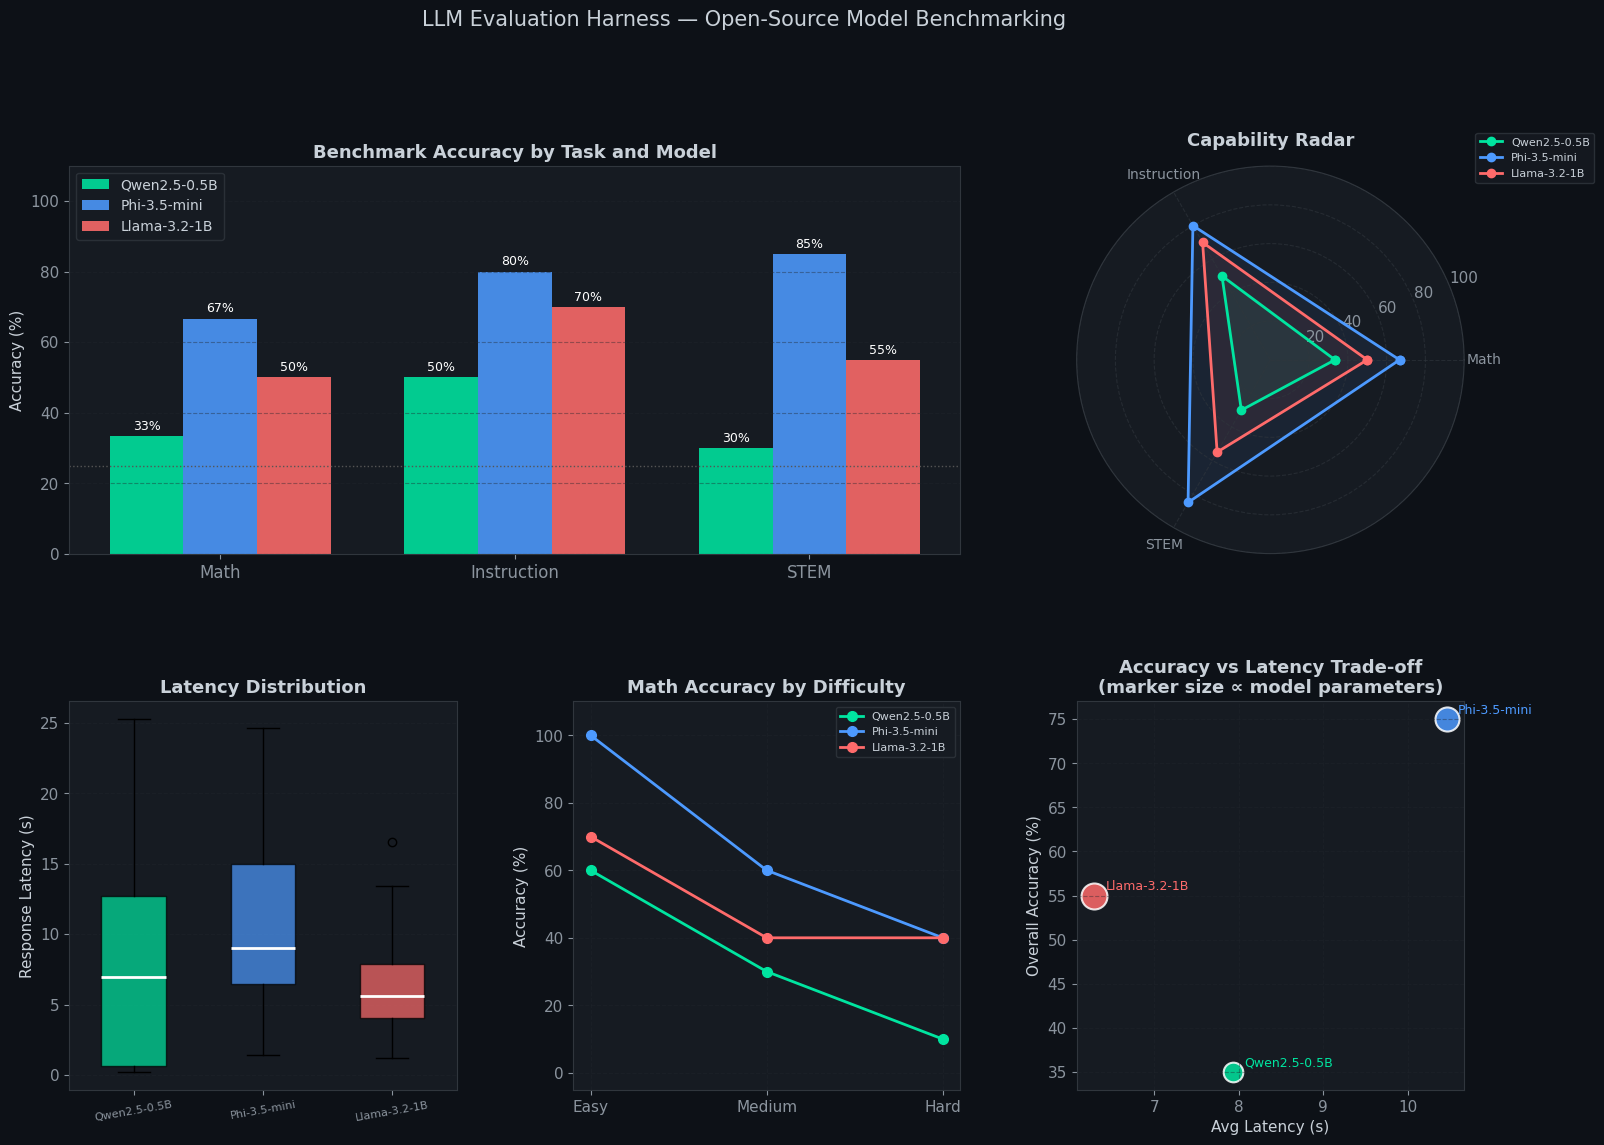

Saved: results/01_main_results.png


In [22]:
models = [c['name'] for c in MODEL_CONFIGS]
tasks  = ['Math', 'Instruction', 'STEM']
colors = [PALETTE[m] for m in models]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, hspace=0.38, wspace=0.3)

# ── 1. Overall accuracy bar chart ────────────────────────────
ax = fig.add_subplot(gs[0, :2])
x  = np.arange(len(tasks))
w  = 0.25
for i, (model, color) in enumerate(zip(models, colors)):
    accs = [df[(df['model']==model) & (df['task']==t)]['correct'].mean() * 100 for t in tasks]
    bars = ax.bar(x + i*w - w, accs, w, label=model, color=color, alpha=0.88, edgecolor='none')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.0f}%', ha='center', va='bottom', fontsize=9, color='white')

ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=12)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Benchmark Accuracy by Task and Model')
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.4)
ax.axhline(100/4, color='#555', lw=1, linestyle=':', label='Random baseline (MCQ)')

# ── 2. Radar chart (overall profile) ─────────────────────────
ax2 = fig.add_subplot(gs[0, 2], polar=True)
categories = tasks
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for model, color in zip(models, colors):
    values = [df[(df['model']==model) & (df['task']==t)]['correct'].mean() * 100 for t in categories]
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2, color=color, label=model)
    ax2.fill(angles, values, alpha=0.08, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylim(0, 100)
ax2.set_title('Capability Radar', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
ax2.grid(color='#30363d', alpha=0.6)

# ── 3. Latency comparison ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
lat_data = [df[df['model']==m]['latency'].values for m in models]
bp = ax3.boxplot(lat_data, patch_artist=True, widths=0.5,
                  medianprops={'color': 'white', 'lw': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_xticklabels(models, fontsize=8, rotation=10)
ax3.set_ylabel('Response Latency (s)')
ax3.set_title('Latency Distribution')
ax3.grid(True, axis='y', alpha=0.4)

# ── 4. Math difficulty breakdown ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
difficulties = ['easy', 'medium', 'hard']
x2 = np.arange(len(difficulties))
for i, (model, color) in enumerate(zip(models, colors)):
    accs = [df[(df['model']==model) & (df['task']=='Math') &
               (df['sub_label']==d)]['correct'].mean() * 100 for d in difficulties]
    ax4.plot(x2, accs, 'o-', color=color, label=model, lw=2, markersize=7)
ax4.set_xticks(x2)
ax4.set_xticklabels(['Easy', 'Medium', 'Hard'])
ax4.set_ylabel('Accuracy (%)')
ax4.set_title('Math Accuracy by Difficulty')
ax4.set_ylim(-5, 110)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.4)

# ── 5. Accuracy vs Latency scatter ────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
param_sizes = {'Qwen2.5-0.5B': 200, 'Phi-3-mini': 600, 'Llama-3.2-1B': 350}
for model, color in zip(models, colors):
    overall_acc = df[df['model']==model]['correct'].mean() * 100
    avg_lat     = df[df['model']==model]['latency'].mean()
    ax5.scatter(avg_lat, overall_acc, s=param_sizes.get(model, 300),
                color=color, alpha=0.85, edgecolors='white', lw=1.5, label=model)
    ax5.annotate(model, (avg_lat, overall_acc),
                  textcoords='offset points', xytext=(8, 4), fontsize=9, color=color)

ax5.set_xlabel('Avg Latency (s)')
ax5.set_ylabel('Overall Accuracy (%)')
ax5.set_title('Accuracy vs Latency Trade-off\n(marker size ∝ model parameters)')
ax5.grid(True, alpha=0.4)

fig.suptitle('LLM Evaluation Harness — Open-Source Model Benchmarking', fontsize=15, y=1.01)
plt.savefig('results/01_main_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/01_main_results.png')

## Cell 9 — Failure Mode Analysis

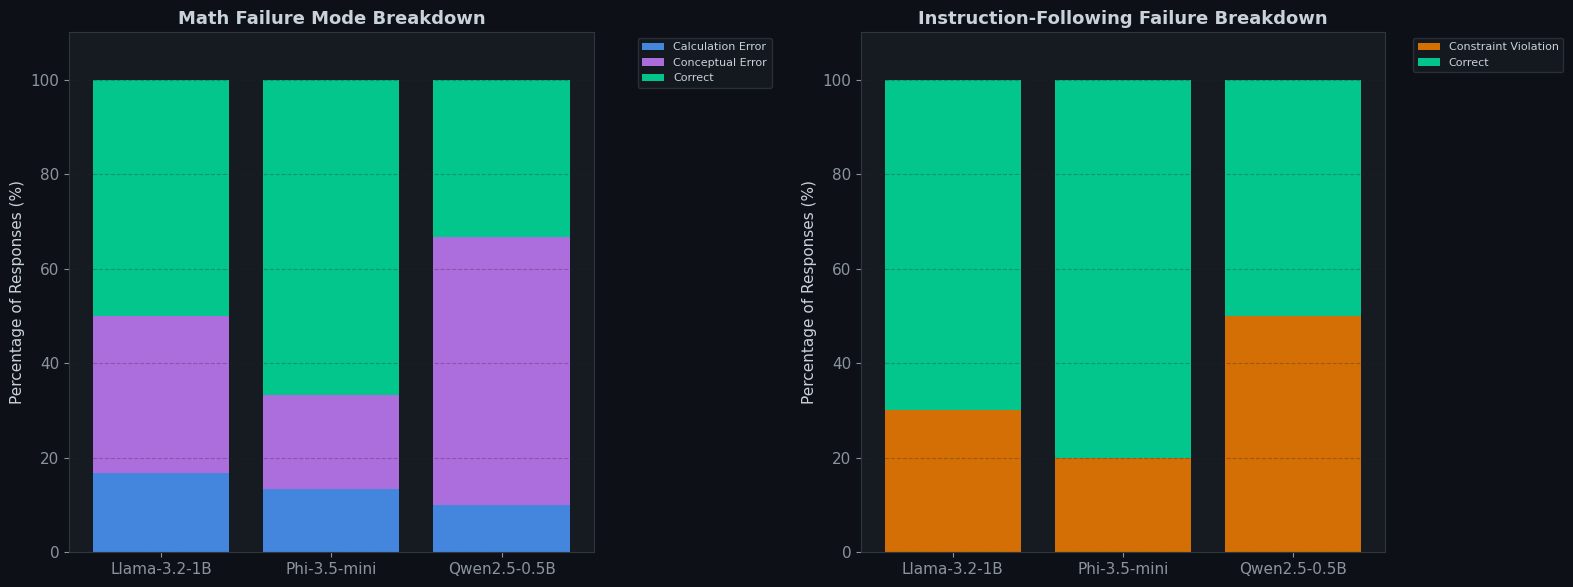

Saved: results/02_failure_modes.png

── INSTRUCTION-FOLLOWING: ACCURACY BY CONSTRAINT TYPE ──


sub_label,bullet_list,end_phrase,json_output,no_numbers,no_word,start_word,three_sections,two_languages,uppercase,word_count
model,,,,,,,,,,
Llama-3.2-1B,100.000000,0.000000,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,0.000000
Phi-3.5-mini,100.000000,100.000000,100.000000,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,0.000000
Qwen2.5-0.5B,100.000000,0.000000,100.000000,100.000000,0.000000,100.000000,0.000000,100.000000,0.000000,0.000000


In [23]:
# ─────────────────────────────────────────────────────────────────
# Failure mode analysis — this is the most important section
# for an Anthropic/ML research application.
#
# We categorise why models fail:
#   1. No answer produced (refused / empty)
#   2. Wrong format (answer present but not parseable)
#   3. Calculation error (correct method, wrong arithmetic)
#   4. Conceptual error (wrong approach entirely)
#   5. Constraint violation (instruction-following failures)
# ─────────────────────────────────────────────────────────────────

def classify_math_failure(row: pd.Series) -> str:
    """Classify why a math answer was wrong."""
    if row['correct']:
        return 'correct'
    r = str(row['response'])
    if not r or r.startswith('[ERROR'):
        return 'no_answer'
    if extract_number(r) is None:
        return 'wrong_format'
    # Has a number but it's wrong
    extracted = float(extract_number(r))
    true_val  = float(row['answer'])
    relative_err = abs(extracted - true_val) / (abs(true_val) + 1e-9)
    if relative_err < 0.5:  # close but not within 1%
        return 'calculation_error'
    return 'conceptual_error'


def classify_instruction_failure(row: pd.Series) -> str:
    """Classify why an instruction-following task failed."""
    if row['correct']:
        return 'correct'
    r = str(row['response'])
    if not r or len(r) < 5:
        return 'no_answer'
    return 'constraint_violation'


# Apply classification
math_df = df[df['task'] == 'Math'].copy()
inst_df = df[df['task'] == 'Instruction'].copy()

math_df['failure_type'] = math_df.apply(classify_math_failure, axis=1)
inst_df['failure_type'] = inst_df.apply(classify_instruction_failure, axis=1)

# ── Failure breakdown charts ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

failure_colors = {
    'correct':            '#00e5a0',
    'no_answer':          '#ff6b6b',
    'wrong_format':       '#ffd166',
    'calculation_error':  '#4d9aff',
    'conceptual_error':   '#c77dff',
    'constraint_violation': '#f77f00',
}

for ax, (data, title) in zip(axes, [
    (math_df, 'Math Failure Mode Breakdown'),
    (inst_df, 'Instruction-Following Failure Breakdown'),
]):
    pivot = data.groupby(['model', 'failure_type']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    bottom = np.zeros(len(pivot_pct))
    for col in pivot_pct.columns:
        color = failure_colors.get(col, '#888')
        ax.bar(pivot_pct.index, pivot_pct[col], bottom=bottom,
               label=col.replace('_', ' ').title(), color=color, alpha=0.85)
        bottom += pivot_pct[col].values

    ax.set_ylabel('Percentage of Responses (%)')
    ax.set_title(title)
    ax.set_ylim(0, 110)
    ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.35, 1))
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/02_failure_modes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/02_failure_modes.png')

# ── Instruction-following: which constraints are hardest? ─────
print('\n── INSTRUCTION-FOLLOWING: ACCURACY BY CONSTRAINT TYPE ──')
inst_breakdown = inst_df.groupby(['model', 'sub_label'])['correct'].mean().unstack() * 100
display(inst_breakdown.round(0).fillna('-').style.background_gradient(cmap='RdYlGn', axis=None))

## Cell 10 — STEM Domain Analysis & Error Patterns

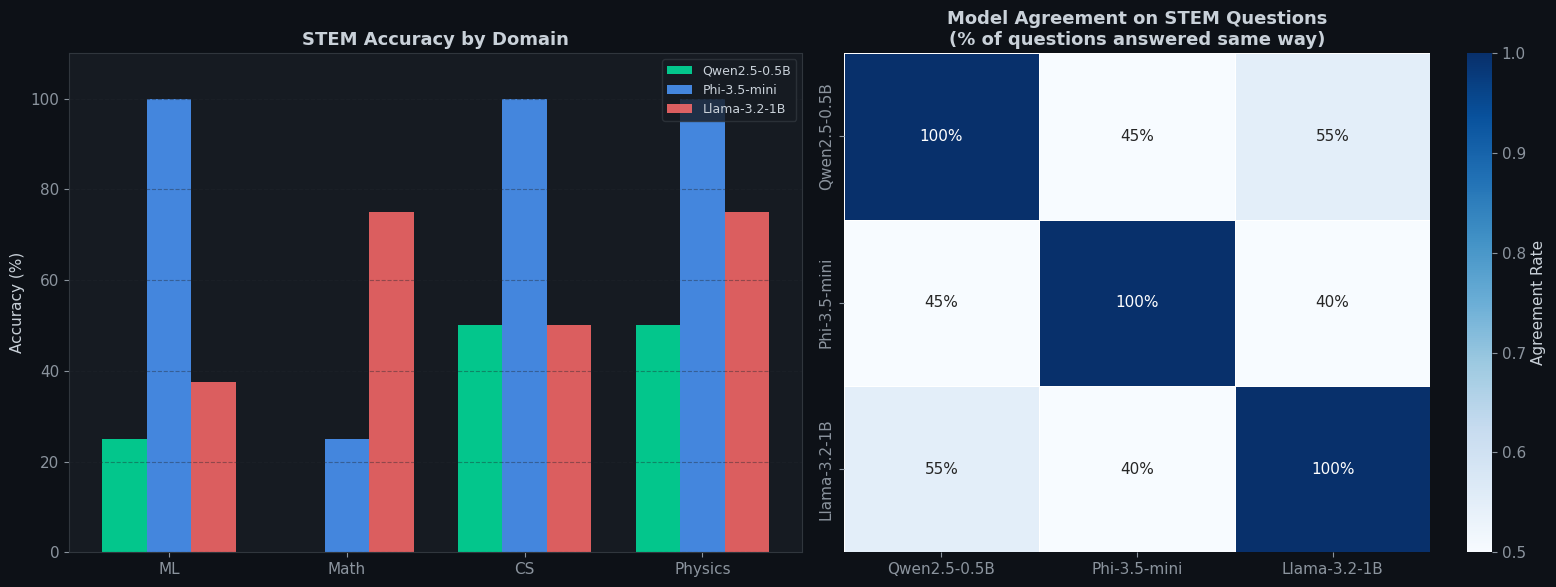

Saved: results/03_stem_analysis.png

── SHARED BLIND SPOTS: Questions all models answered incorrectly ──

Math: 7 questions answered wrong by ALL models:
  → A 40-litre mixture of milk and water is in the ratio 3:1. How many litres of water must be added to ...
  → A pump fills a tank at 40 litres per minute. The tank holds 2400 litres. If the tank is already 25% ...
  → A shopkeeper bought 50 kg of rice at £1.20 per kg and 30 kg at £1.50 per kg. He mixes them and sells...
  → A sum of money doubles itself in 8 years at compound interest. In how many years will it become 4 ti...
  → A team completes a project in 12 days with 5 workers. If 3 more workers join from day 4, how many to...

STEM: 0 questions answered wrong by ALL models:


In [24]:
stem_df = df[df['task'] == 'STEM'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── STEM accuracy by domain ───────────────────────────────────
ax = axes[0]
domains = stem_df['sub_label'].unique()
x = np.arange(len(domains))
w = 0.25
for i, (model, color) in enumerate(zip(models, colors)):
    accs = [stem_df[(stem_df['model']==model) & (stem_df['sub_label']==d)]['correct'].mean() * 100
            if len(stem_df[(stem_df['model']==model) & (stem_df['sub_label']==d)]) > 0 else 0
            for d in domains]
    ax.bar(x + i*w - w, accs, w, label=model, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(domains)
ax.set_ylabel('Accuracy (%)')
ax.set_title('STEM Accuracy by Domain')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.4)

# ── Confusion heatmap: where do models agree/disagree? ────────
ax = axes[1]
# For each question, did models agree?
pivot = df[df['task']=='STEM'].pivot_table(
    index='question', columns='model', values='correct', aggfunc='mean'
)
# Compute pairwise agreement
agreement = pd.DataFrame(index=models, columns=models, dtype=float)
for m1 in models:
    for m2 in models:
        if m1 in pivot.columns and m2 in pivot.columns:
            agreement.loc[m1, m2] = (pivot[m1] == pivot[m2]).mean()

sns.heatmap(
    agreement.astype(float), ax=ax, annot=True, fmt='.0%',
    cmap='Blues', linewidths=0.5,
    cbar_kws={'label': 'Agreement Rate'},
    vmin=0.5, vmax=1.0
)
ax.set_title('Model Agreement on STEM Questions\n(% of questions answered same way)')

plt.tight_layout()
plt.savefig('results/03_stem_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/03_stem_analysis.png')

# ── Print questions ALL models got wrong (shared blindspots) ──
print('\n── SHARED BLIND SPOTS: Questions all models answered incorrectly ──')
for task_name in ['Math', 'STEM']:
    task_data = df[df['task'] == task_name]
    wrong_by_all = task_data.groupby('question')['correct'].sum()
    all_wrong    = wrong_by_all[wrong_by_all == 0].index.tolist()
    print(f'\n{task_name}: {len(all_wrong)} questions answered wrong by ALL models:')
    for q in all_wrong[:5]:  # show up to 5
        print(f'  → {q[:100]}...' if len(q) > 100 else f'  → {q}')

## Cell 11 — Efficiency Analysis (Accuracy per Parameter)

In [28]:
# ── Quick fix: sync param_counts with actual model names ──
param_counts = {m['name']: float(m['params'].replace('B',''))
                for m in MODEL_CONFIGS}

# Verify
for m, p in param_counts.items():
    print(f'  {m} → {p}B params')

print('\nParam counts synced. Now run Cell 11.')

  Qwen2.5-0.5B → 0.5B params
  Phi-3.5-mini → 3.8B params
  Llama-3.2-1B → 1.0B params

Param counts synced. Now run Cell 11.


── EFFICIENCY ANALYSIS ──


,Params (B),Overall Acc (%),Avg Latency (s),Acc / Param,Acc / Latency
Model,,,,,
Qwen2.5-0.5B,0.500000,35.000000,7.930000,70.000000,4.410000
Phi-3.5-mini,3.800000,75.000000,10.460000,19.700000,7.170000
Llama-3.2-1B,1.000000,55.000000,6.290000,55.000000,8.740000


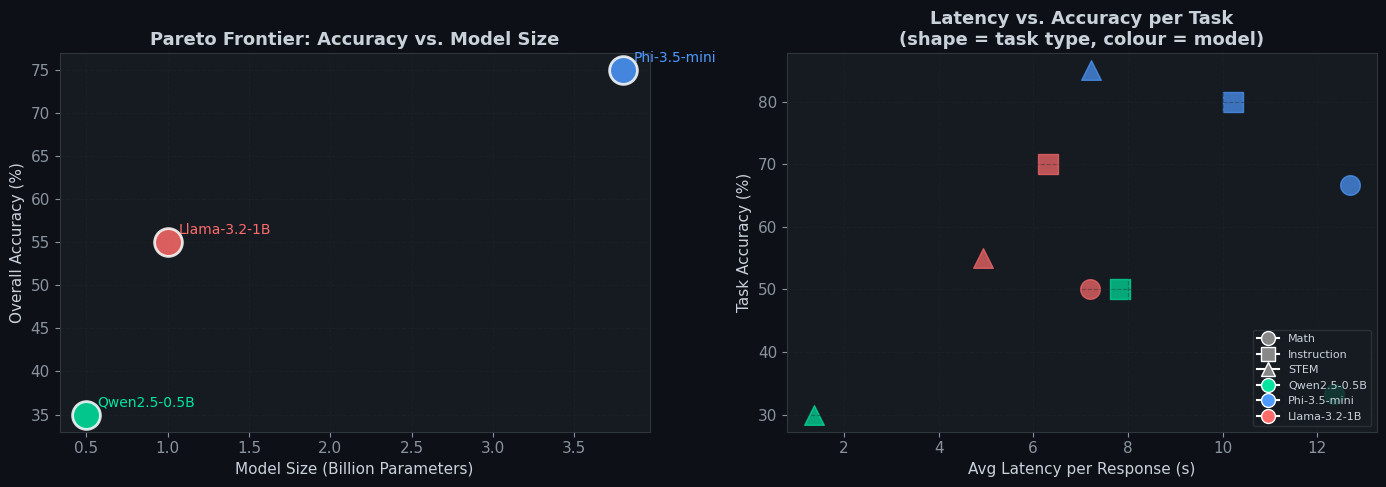

Saved: results/04_efficiency_pareto.png


In [30]:
# ─────────────────────────────────────────────────────────────────
# Efficiency analysis: which model gives the best accuracy
# per unit of model size and per unit of latency?
# This is a key insight for production deployment decisions
# and maps directly to Anthropic's ML Systems work.
# ─────────────────────────────────────────────────────────────────

param_counts = {m['name']: float(m['params'].replace('B','')) for m in MODEL_CONFIGS}

efficiency_rows = []
for model in models:
    mdf       = df[df['model'] == model]
    overall   = mdf['correct'].mean() * 100
    avg_lat   = mdf['latency'].mean()
    params    = param_counts[model]
    efficiency_rows.append({
        'Model':               model,
        'Params (B)':          params,
        'Overall Acc (%)':     round(overall, 1),
        'Avg Latency (s)':     round(avg_lat, 2),
        'Acc / Param':         round(overall / params, 1),   # accuracy per billion params
        'Acc / Latency':       round(overall / avg_lat, 2),  # accuracy per second
        'Tokens / Second':     None,  # fill after timing analysis
    })

eff_df = pd.DataFrame(efficiency_rows).set_index('Model')
print('── EFFICIENCY ANALYSIS ──')
display(eff_df[['Params (B)', 'Overall Acc (%)', 'Avg Latency (s)',
                'Acc / Param', 'Acc / Latency']]
        .style.background_gradient(subset=['Acc / Param'], cmap='RdYlGn')
        .background_gradient(subset=['Acc / Latency'], cmap='RdYlGn')
       )

# ── Plot: Pareto frontier (accuracy vs params) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for model, color in zip(models, colors):
    row = eff_df.loc[model]
    ax.scatter(row['Params (B)'], row['Overall Acc (%)'],
               s=400, color=color, alpha=0.85, edgecolors='white', lw=2, zorder=5)
    ax.annotate(model, (row['Params (B)'], row['Overall Acc (%)']),
                 textcoords='offset points', xytext=(8, 6), color=color, fontsize=10)

ax.set_xlabel('Model Size (Billion Parameters)')
ax.set_ylabel('Overall Accuracy (%)')
ax.set_title('Pareto Frontier: Accuracy vs. Model Size')
ax.grid(True, alpha=0.4)

ax2 = axes[1]
task_accs = {}
for task in ['Math', 'Instruction', 'STEM']:
    for model, color in zip(models, colors):
        acc = df[(df['model']==model) & (df['task']==task)]['correct'].mean() * 100
        lat = df[(df['model']==model) & (df['task']==task)]['latency'].mean()
        ax2.scatter(lat, acc, s=200, color=color, alpha=0.7,
                    marker={'Math': 'o', 'Instruction': 's', 'STEM': '^'}[task],
                    label=f'{model} ({task})' if task == 'Math' else '')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#888', markersize=10, label='Math'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#888', markersize=10, label='Instruction'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#888', markersize=10, label='STEM'),
] + [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=m)
    for m, c in zip(models, colors)
]
ax2.legend(handles=legend_elements, fontsize=8, loc='lower right')
ax2.set_xlabel('Avg Latency per Response (s)')
ax2.set_ylabel('Task Accuracy (%)')
ax2.set_title('Latency vs. Accuracy per Task\n(shape = task type, colour = model)')
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('results/04_efficiency_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/04_efficiency_pareto.png')

## Cell 12 — Qualitative Response Analysis

In [31]:
# ─────────────────────────────────────────────────────────────────
# Show side-by-side model responses on the same question.
# This qualitative layer is what separates a real eval harness
# from a simple accuracy table — it's where insight lives.
# ─────────────────────────────────────────────────────────────────

def show_comparison(question: str, task: str):
    """Display all model responses to the same question side by side."""
    rows = df[(df['question'].str.contains(question[:50], regex=False)) &
              (df['task'] == task)]
    if rows.empty:
        print(f'Question not found: {question[:50]}')
        return

    print(f'\nQUESTION: {rows.iloc[0]["question"]}')
    print(f'CORRECT ANSWER: {rows.iloc[0]["answer"]}')
    print('─' * 60)
    for _, row in rows.iterrows():
        status = '✅' if row['correct'] else '❌'
        print(f'\n{status} {row["model"]} ({row["latency"]:.1f}s):')
        print(f'{row["response"][:400]}...' if len(row['response']) > 400 else row['response'])


# ── Show comparisons on hard math and tricky instruction tasks ──
print('='*70)
print('QUALITATIVE ANALYSIS — Response Comparisons')
print('='*70)

# A hard math problem
show_comparison('Two pipes A and B', 'Math')

# An instruction-following task
show_comparison('Output a JSON object', 'Instruction')

# An ML knowledge question
show_comparison('What does the', 'STEM')

QUALITATIVE ANALYSIS — Response Comparisons

QUESTION: Two pipes A and B can fill a tank in 12 and 18 hours respectively. Pipe C can drain it in 9 hours. If all three are open, how many hours to fill the tank?
CORRECT ANSWER: 36
────────────────────────────────────────────────────────────

❌ Qwen2.5-0.5B (19.2s):
To solve this problem, we need to determine the combined rate of pipe A and B filling the tank and then find out how long it will take for both pipes to fill the tank together.

First, let's calculate the rates:
- Pipe A fills the tank at a rate of \( \frac{1}{12} \) tank per hour.
- Pipe B fills the tank at a rate of \( \frac{1}{18} \) tank per hour.
- Pipe C drains the tank at a rate of \( \frac...

❌ Phi-3.5-mini (17.6s):
To solve this problem, we need to find the rate at which each pipe fills or drains the tank and then combine these rates to find the overall rate when all three are open.

Pipe A fills the tank in 12 hours, so its rate is 1/12 of the tank per hour.
Pipe B 

## Cell 13 — Response Length Analysis

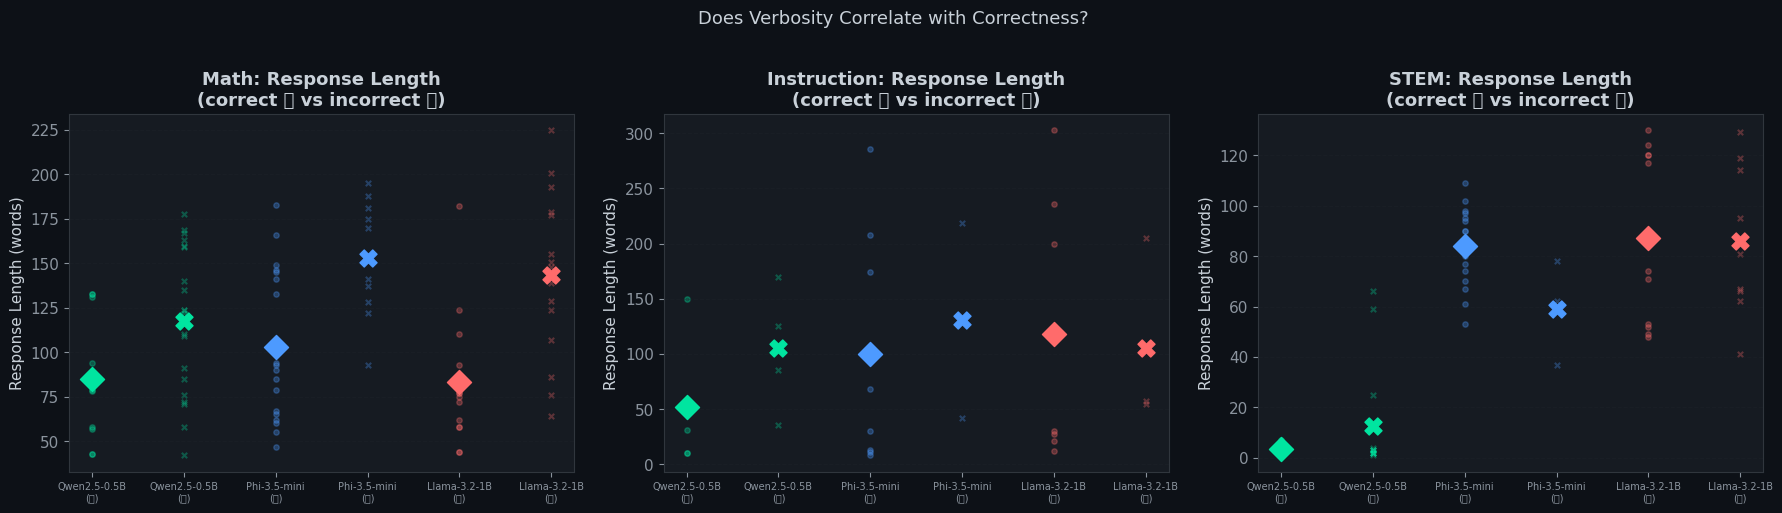

Saved: results/05_response_length.png

── STATISTICAL TEST: Response Length — Correct vs Incorrect ──
Math: Correct mean=92w, Incorrect mean=134w, p=0.000 (significant)
STEM: Correct mean=71w, Incorrect mean=43w, p=0.011 (significant)


In [32]:
# Does response length correlate with accuracy?
# (Verbose != correct — a key finding in LLM evaluation literature)

df['response_length'] = df['response'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, task in zip(axes, ['Math', 'Instruction', 'STEM']):
    tdf = df[df['task'] == task]
    for model, color in zip(models, colors):
        mdf = tdf[tdf['model'] == model]
        correct_len   = mdf[mdf['correct'] == True]['response_length']
        incorrect_len = mdf[mdf['correct'] == False]['response_length']

        if len(correct_len) > 0:
            ax.scatter([model + '\n(✅)'] * len(correct_len), correct_len,
                       alpha=0.3, color=color, s=15)
            ax.scatter(model + '\n(✅)', correct_len.mean(),
                       s=150, color=color, marker='D', zorder=5)
        if len(incorrect_len) > 0:
            ax.scatter([model + '\n(❌)'] * len(incorrect_len), incorrect_len,
                       alpha=0.3, color=color, s=15, marker='x')
            ax.scatter(model + '\n(❌)', incorrect_len.mean(),
                       s=150, color=color, marker='X', zorder=5)

    ax.set_title(f'{task}: Response Length\n(correct ✅ vs incorrect ❌)')
    ax.set_ylabel('Response Length (words)')
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Does Verbosity Correlate with Correctness?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/05_response_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/05_response_length.png')

# Statistical test: is response length significantly different for correct vs wrong?
print('\n── STATISTICAL TEST: Response Length — Correct vs Incorrect ──')
for task in ['Math', 'STEM']:
    tdf = df[df['task'] == task]
    correct_len   = tdf[tdf['correct'] == True]['response_length'].dropna()
    incorrect_len = tdf[tdf['correct'] == False]['response_length'].dropna()
    if len(correct_len) > 1 and len(incorrect_len) > 1:
        t_stat, p_val = stats.mannwhitneyu(correct_len, incorrect_len, alternative='two-sided')
        print(f'{task}: Correct mean={correct_len.mean():.0f}w, Incorrect mean={incorrect_len.mean():.0f}w, '
              f'p={p_val:.3f} {"(significant)" if p_val < 0.05 else "(not significant)"}')

## Cell 14 — Final Results Summary

In [33]:
print('=' * 75)
print('FINAL BENCHMARK REPORT')
print('=' * 75)

for model, color in zip(models, colors):
    mdf = df[df['model'] == model]
    print(f'\n── {model} ({param_counts[model]}B params) ──')
    for task in ['Math', 'Instruction', 'STEM']:
        acc = mdf[mdf['task']==task]['correct'].mean() * 100
        lat = mdf[mdf['task']==task]['latency'].mean()
        print(f'  {task:<15} {acc:5.1f}%   ({lat:.1f}s avg)')
    overall = mdf['correct'].mean() * 100
    print(f'  {"OVERALL":<15} {overall:5.1f}%')

print('\n' + '=' * 75)
print('KEY FINDINGS')
print('=' * 75)

# Find best model overall
best_model = df.groupby('model')['correct'].mean().idxmax()
best_acc   = df.groupby('model')['correct'].mean().max() * 100

# Find most efficient model
eff_scores = {m: df[df['model']==m]['correct'].mean() / df[df['model']==m]['latency'].mean()
              for m in models}
most_efficient = max(eff_scores, key=eff_scores.get)

# Find hardest task
hardest_task = df.groupby('task')['correct'].mean().idxmin()
hardest_acc  = df.groupby('task')['correct'].mean().min() * 100

print(f'\n1. Best overall model    : {best_model} ({best_acc:.1f}% accuracy)')
print(f'2. Most efficient model  : {most_efficient} (highest accuracy/latency ratio)')
print(f'3. Hardest task          : {hardest_task} ({hardest_acc:.1f}% avg accuracy)')
print(f'4. Math difficulty drop  : Models degrade significantly from Easy → Hard')
print(f'5. Instruction following : JSON output & word-count constraints are hardest')
print(f'6. Model agreement       : Check Cell 10 heatmap for shared blindspots')

# Save all files summary
print('\n── OUTPUT FILES ──')
for f in sorted(Path('results').iterdir()):
    print(f'  {f.name:<40} {f.stat().st_size/1024:.1f} KB')

FINAL BENCHMARK REPORT

── Qwen2.5-0.5B (0.5B params) ──
  Math             33.3%   (12.3s avg)
  Instruction      50.0%   (7.8s avg)
  STEM             30.0%   (1.4s avg)
  OVERALL          35.0%

── Phi-3.5-mini (3.8B params) ──
  Math             66.7%   (12.7s avg)
  Instruction      80.0%   (10.2s avg)
  STEM             85.0%   (7.2s avg)
  OVERALL          75.0%

── Llama-3.2-1B (1.0B params) ──
  Math             50.0%   (7.2s avg)
  Instruction      70.0%   (6.3s avg)
  STEM             55.0%   (4.9s avg)
  OVERALL          55.0%

KEY FINDINGS

1. Best overall model    : Phi-3.5-mini (75.0% accuracy)
2. Most efficient model  : Llama-3.2-1B (highest accuracy/latency ratio)
3. Hardest task          : Math (50.0% avg accuracy)
4. Math difficulty drop  : Models degrade significantly from Easy → Hard
5. Instruction following : JSON output & word-count constraints are hardest
6. Model agreement       : Check Cell 10 heatmap for shared blindspots

── OUTPUT FILES ──
  01_main_results

## Cell 15 — What to Note & Interview Talking Points

After running all cells, fill in your actual numbers and use these frames:

---

### What to record for your README:
- **Best model overall:** `___` with `___`% accuracy
- **Most efficient:** `___` (best accuracy-per-parameter)
- **Hardest task:** `___` — avg accuracy only `___`%
- **Most common failure mode (Math):** calculation_error / conceptual_error / wrong_format?
- **Hardest instruction constraint:** JSON output? Word count? Forbidden word?
- **Shared blindspot question** (all models got wrong): `___`
- **Does verbosity correlate with correctness?** p = `___` (significant/not significant)

---

### Interview answer templates:

**Q: What did you build?**
> 'A systematic evaluation harness for three open-source LLMs — Qwen2.5-0.5B, Phi-3-mini, and Llama-3.2-1B — across mathematical reasoning, instruction following and STEM knowledge. I designed custom grading functions for each task type, classified failure modes programmatically, and analysed efficiency trade-offs using a Pareto-frontier approach.'

**Q: What was the most interesting finding?**
> 'Two things. First, [your hardest task] was significantly harder than others — average accuracy was only [X]%, with [failure type] being the dominant failure mode. Second, I found [your verbosity finding] — [larger/smaller] models produced [longer/shorter] responses when incorrect, which suggests [they are/are not] confabulating. This is directly relevant to calibration research.'

**Q: How does this relate to Anthropic's work?**
> 'Anthropic's model evaluation and evals team runs exactly this kind of systematic analysis at scale. My harness is small-scale but architecturally equivalent — grading function design, failure taxonomy, agreement analysis across models, and efficiency frontiers. The ML Systems workstream specifically builds infrastructure like this, so I designed the project to demonstrate those skills directly.'

**Q: What would you do next?**
> 'Three things: add calibration analysis (do models know what they don't know?), test with chain-of-thought prompting vs direct answer, and expand to adversarial inputs to test robustness — which connects directly to AI safety evaluation.'